In [12]:
import fastcubo
import ee
import satalign

In [2]:
ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

In [3]:
table = fastcubo.query_getPixels_imagecollection(
    point=(-119.68553947009042,36.80065496560349),
    collection="COPERNICUS/S2_HARMONIZED",
    bands = ["B2", "B3", "B4", "B8"],
    data_range=["2017-01-01", "2024-12-31"],
    edge_size=256, 
    resolution=10, 
)
fastcubo.getPixels(table, nworkers=4, output_path=r"D:\Aligned_image\s2")

[WindowsPath('D:/Aligned_image/s2/20170107T184741_20170107T185402_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/20170107T184741_20170107T185402_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170107T184741_20170107T184740_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170107T184741_20170107T184740_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/20170117T184711_20170117T184707_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170127T184631_20170127T184627_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170117T184711_20170117T184707_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/20170127T184631_20170127T184627_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/20170216T184431_20170216T185205_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170216T184431_20170216T185205_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/20170226T184321_20170226T184600_T10SGF.tif'),
 WindowsPath('D:/Aligned_image/s2/20170226T184321_20170226T184600_T11SKA.tif'),
 WindowsPath('D:/Aligned_image/s2/201704

In [13]:
s2_datacube = satalign.utils.create_array(r"D:\Aligned_image\s2", "datacube.pickle")

Creating data cube...


In [14]:
reference_image = s2_datacube.sel(time=s2_datacube.time > "2022-01-03").mean("time")


In [15]:
syncmodel = satalign.PCC(
    datacube=s2_datacube, # T x C x H x W
    reference=reference_image, # C x H x W
    channel="mean",
    crop_center=128,
    num_threads=2,
)
news2cube, warps = syncmodel.run_multicore()



d:\GitHub\satalign\satalign\pcc.py:78: UserWarning: Could not determine RMS error between images with the normalized average intensities 300500810111144.8 and 0.0. Either the reference or moving image may be empty.
  shift, error, diffphase = phase_cross_correlation(
d:\GitHub\satalign\satalign\main.py:240: UserWarning: Estimated translation is too large
  warnings.warn("Estimated translation is too large")


In [17]:
news2cube

<xarray.DataArray (time: 1020, band: 4, y: 256, x: 256)> Size: 535MB
array([[[[10081, 10112, 10087, ..., 10949, 10972, 10876],
         [10059, 10072, 10068, ..., 10967, 10973, 10908],
         [10028, 10084, 10028, ..., 10948, 10929, 10889],
         ...,
         [ 8722,  8682,  8617, ...,  8891,  8907,  8952],
         [ 8739,  8684,  8668, ...,  8818,  8890,  8916],
         [ 8716,  8688,  8676, ...,  8802,  8866,  8884]],

        [[ 9551,  9543,  9556, ..., 10322, 10351, 10314],
         [ 9519,  9568,  9565, ..., 10344, 10332, 10318],
         [ 9524,  9555,  9552, ..., 10312, 10335, 10297],
         ...,
         [ 8095,  8089,  8088, ...,  8317,  8305,  8327],
         [ 8094,  8057,  8069, ...,  8299,  8296,  8325],
         [ 8092,  8077,  8078, ...,  8273,  8279,  8325]],

        [[10264, 10245, 10232, ..., 11018, 10976, 10942],
         [10201, 10228, 10227, ..., 11032, 10981, 10930],
         [10242, 10243, 10177, ..., 11002, 10996, 10949],
         ...,
...
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]],

        [[    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         ...,
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0],
         [    0,     0,     0, ...,     0,     0,     0]]]], dtype=uint16)
Coordinates:
  * time     (time) <U8 33kB '20170107' '20170107' ... '20240818' '20240818'
  * band     (band) int32 16B 1 2 3 4
  * y        (y) float64 2kB 4.077e+06 4.077e+06 ... 4.075e+06 4.075e+06
  * x        (x) float64 2kB 2.591e+05 2.591e+05 ... 2.617e+05 2.617e+05

In [18]:
import rasterio
from rasterio.transform import from_origin

# Suponiendo que 'aligned_images' es tu xarray.DataArray con las imágenes alineadas
aligned_images = news2cube

# Parámetros de transformación (pueden variar según tus datos)
transform = from_origin(aligned_images.coords['x'][0], aligned_images.coords['y'][0], aligned_images.coords['x'][1] - aligned_images.coords['x'][0], aligned_images.coords['y'][1] - aligned_images.coords['y'][0])

# Guardar cada imagen como un TIFF
for i, date in enumerate(aligned_images.coords['time'].values):
    # Define el nombre de archivo basado en la fecha o índice
    output_filename = f"aligned_image_{date}.tif"

    # Configura el perfil del archivo TIFF
    with rasterio.open(
        output_filename,
        'w',
        driver='GTiff',
        height=aligned_images.shape[2],
        width=aligned_images.shape[3],
        count=aligned_images.shape[1],  # Número de bandas
        dtype=aligned_images.dtype,
        crs="EPSG:4326",  # Asumiendo que tus datos están en WGS84
        transform=transform,
    ) as dst:
        for band in range(aligned_images.shape[1]):
            dst.write(aligned_images[i, band, :, :].values, band + 1)

In [9]:
import matplotlib.pyplot as plt

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

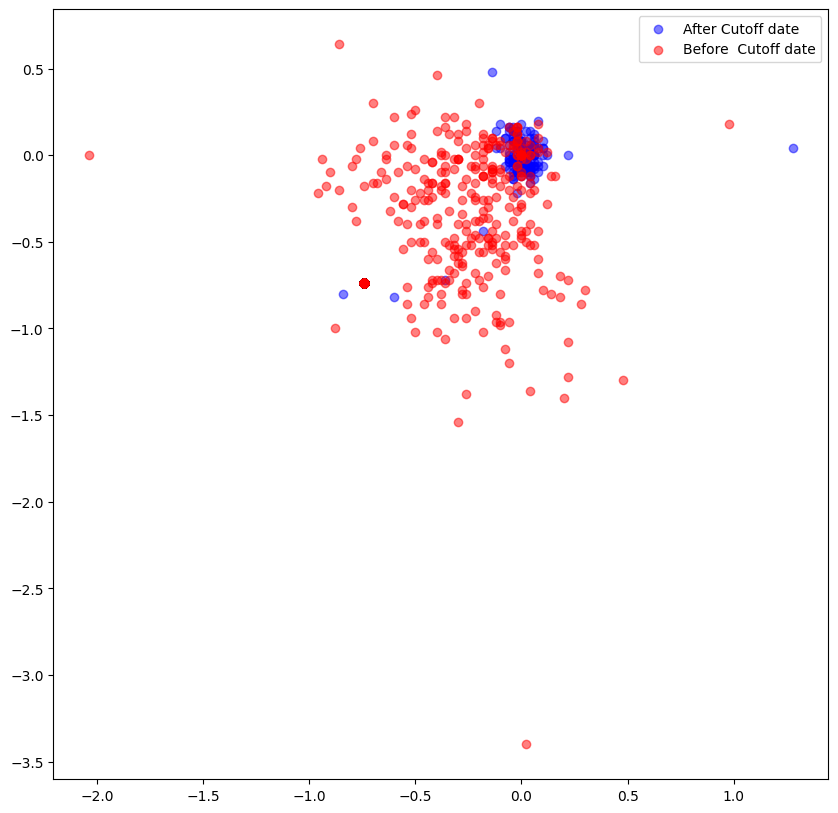

In [10]:
# plot scatter plot
warp_df = satalign.utils.warp2df(warps, s2_datacube.time.values)
satalign.utils.plot_s2_scatter(warp_df)

(<Figure size 1000x500 with 2 Axes>,
 array([<Axes: title={'center': 'Original Cube'}, xlabel='X axis - 3', ylabel='Time'>,
        <Axes: title={'center': 'Aligned Cube'}, xlabel='X axis - 3', ylabel='Time'>],
       dtype=object))

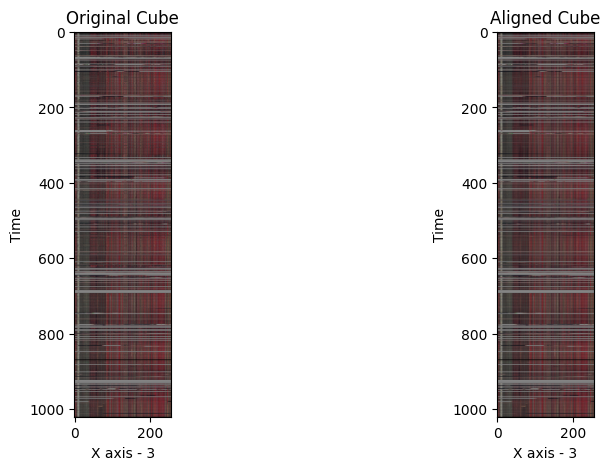

In [11]:
# plot profiles
satalign.utils.plot_profile(
    warped_cube=news2cube.values,
    raw_cube=s2_datacube.values,
    x_axis=3,
    y_axis=None,
    rgb_band=[3, 2, 1],
    intensity_factor=1/3000,
)

In [ ]:
gifspath = satalign.utils.plot_animation1(
    warped_cube=news2cube[0:50].values,
    raw_cube=s2_datacube[0:50].values,
    dates=s2_datacube.time[0:50].values,
    rgb_band=[3, 2, 1],
    intensity_factor=1/3000,
    png_output_folder=r"D:\Aligned_image\s2",
    gif_delay=20,
    gif_output_file=r"D:\Aligned_image\s2animation1.gif",
)

In [50]:

import os
gif_loop = 0
path_png = os.path.join(png_output_folder, "*.png")
try:
    print("Creating the gif...")
    os.system(
        f"magick -delay {gif_delay} -loop {gif_loop} {path_png} {gif_output_file}"
    )
except Exception as e:
    print(e)
    raise ValueError("Error creating the gif")

Creating image 0 of 50
Creating image 1 of 50
Creating image 2 of 50
Creating image 3 of 50
Creating image 4 of 50
Creating image 5 of 50
Creating image 6 of 50
Creating image 7 of 50
Creating image 8 of 50
Creating image 9 of 50
Creating image 10 of 50
Creating image 11 of 50
Creating image 12 of 50
Creating image 13 of 50
Creating image 14 of 50
Creating image 15 of 50
Creating image 16 of 50
Creating image 17 of 50
Creating image 18 of 50
Creating image 19 of 50
Creating image 20 of 50
Creating image 21 of 50
Creating image 22 of 50
Creating image 23 of 50
Creating image 24 of 50
Creating image 25 of 50
Creating image 26 of 50
Creating image 27 of 50
Creating image 28 of 50
Creating image 29 of 50
Creating image 30 of 50
Creating image 31 of 50
Creating image 32 of 50
Creating image 33 of 50
Creating image 34 of 50
Creating image 35 of 50
Creating image 36 of 50
Creating image 37 of 50
Creating image 38 of 50
Creating image 39 of 50
Creating image 40 of 50
Creating image 41 of 50
Cr

<Figure size 640x480 with 0 Axes>

In [ ]:
os.system(
    f"magick -delay {gif_delay} -loop {gif_loop} {path_png} {gif_output_file}"
)

1

In [60]:
os.system("magick -delay 2 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif")

1

In [62]:
import subprocess

command = [
    "magick",
    "-delay", "2",
    "-loop", "0",
    "D:\\Aligned_image\\s2\\png\\*.png",
    "D:\\Aligned_image\\s2\\png\\s2animation1.gif"
]

subprocess.run('cmd /k ' + ' '.join(command), shell=True)

CompletedProcess(args=['powershell', '-Command', 'Start-Process powershell -ArgumentList "magick -delay 20 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif" -Verb RunAs'], returncode=0)

In [4]:
import subprocess

# Comando de PowerShell para ejecutar `magick` sin elevación de permisos
command = 'magick -delay 2 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif'

# Ejecutar el comando en PowerShell
subprocess.run(["powershell", "-Command", command], shell=True)

CompletedProcess(args=['powershell', '-Command', 'magick -delay 2 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif'], returncode=1)

In [55]:
try:
    print("Creating the gif...")
    os.system(
        f"magick -delay {gif_delay} -loop {gif_loop} {path_png} {gif_output_file}"
    )
    print("1")
except Exception as e:
    print(e)
    raise ValueError("Error creating the gif")

Creating the gif...
1


Creating the gif...


In [43]:
import os

os.system(
    f"magick -size {0} -loop {0} {'D:/Aligned_image/s2/png'}/*.png {'D:\\Aligned_image\\s2\\png\\s2animation1.gif'}"
)

1

In [48]:
f"magick -delay {0} -loop {0} {'D:\Aligned_image\s2\png'}\*.png {'D:\Aligned_image\s2\png\s2animation1.gif'}"

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\*'
<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\*'
C:\Users\contr\AppData\Local\Temp\ipykernel_15800\1674249236.py:1: SyntaxWarning: invalid escape sequence '\A'
  f"magick -delay {0} -loop {0} {'D:\Aligned_image\s2\png'}\*.png {'D:\Aligned_image\s2\png\s2animation1.gif'}"
C:\Users\contr\AppData\Local\Temp\ipykernel_15800\1674249236.py:1: SyntaxWarning: invalid escape sequence '\A'
  f"magick -delay {0} -loop {0} {'D:\Aligned_image\s2\png'}\*.png {'D:\Aligned_image\s2\png\s2animation1.gif'}"
C:\Users\contr\AppData\Local\Temp\ipykernel_15800\1674249236.py:1: SyntaxWarning: invalid escape sequence '\*'
  f"magick -delay {0} -loop {0} {'D:\Aligned_image\s2\png'}\*.png {'D:\Aligned_image\s2\png\s2animation1.gif'}"


'magick -delay 0 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif'

In [53]:
f"magick -delay {gif_delay} -loop {gif_loop} {path_png} {gif_output_file}"

'magick -delay 2 -loop 0 D:\\Aligned_image\\s2\\png\\*.png D:\\Aligned_image\\s2\\png\\s2animation1.gif'